In [1]:
from model import Model

In [2]:
import os

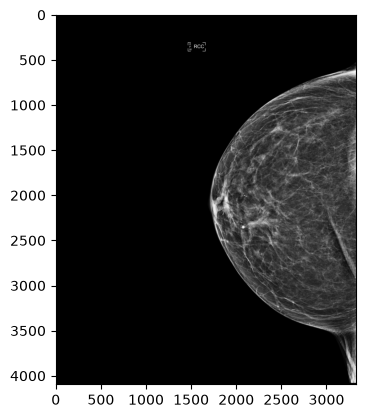

In [3]:
from skimage.io import imread
import matplotlib.pyplot  as plt

image = imread('/workspace/data/RSNA_png/train_images/25/822390278.png')

# image = imread('/workspace/code/sample_data/images/3_L-MLO.png')
plt.imshow(image, cmap='gray')
plt.show()

In [4]:
from predictor import Predictor

In [5]:
pred = Predictor()

In [6]:
score, map = pred.predict(image)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [11]:
from preprocessing import Preprocessing

In [12]:
metadata = {'laterality':'L','view':'MLO'}

In [13]:
Preprocessing(image,metadata)

L-MLO


tensor([[[[-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362],
          [-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362],
          [-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362],
          ...,
          [-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362],
          [-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362],
          [-0.5362, -0.5362, -0.5362,  ..., -0.5362, -0.5362, -0.5362]]]])

In [ ]:
saliency_maps = pred.model.get_network().saliency_map.data.cpu().numpy()

malignant_saliency_map = saliency_maps[0,1,:,:]


In [ ]:
import numpy as np
print(malignant_saliency_map.shape)
print(np.max(malignant_saliency_map))
print(np.min(malignant_saliency_map))

In [ ]:
from skimage.transform import resize

In [ ]:
map = resize(malignant_saliency_map, image.shape)

In [ ]:
#alpha_red = plt.colormaps['Reds']
cmap = plt.colormaps['hot']

fig, ax = plt.subplots(figsize=(15,5))
ax.imshow(image, cmap="grey")
img = ax.imshow(map, alpha=0.3, cmap=cmap, clim=[0.0, 1.0])
ax.axis("off")
plt.show()

# Post the Colorbar:
ticks = np.linspace(0, np.max(map), 10, dtype=int)
cbar = plt.colorbar(img, ax=ax, shrink=0.6, ticks=ticks, fraction=0.046, pad=0.04)

cbar.set_label('Score', fontsize=15)
#cbar.ax.set_yticklabels(list(map(str, ticks)))


In [ ]:
print(np.max(map))
print(np.min(map))